In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load PLINK PCA file (no header)
pca = pd.read_csv('../data/final_dataset/pca_ldpruned/pca_ldpruned.eigenvec', delim_whitespace=True, header=None)

# Add column names: FID, IID, PC1, PC2, ..., PC10
num_pcs = pca.shape[1] - 2
pc_cols = [f'PC{i+1}' for i in range(num_pcs)]
pca.columns = ['FID', 'IID'] + pc_cols

In [3]:
eigenvals = pd.read_csv('../data/final_dataset/pca_ldpruned/pca_ldpruned.eigenval', header=None).squeeze()
variance_explained = 100 * eigenvals / eigenvals.sum()

In [4]:
# Load metadata
metadata = pd.read_csv('../data/final_dataset/metadata.txt', sep="\t")

# Check first few lines to confirm columns
print(metadata.head())

    user build            chip chip_version inferred_sex  \
0  10645    37             NaN          NaN       Female   
1  10542    37  HTS iSelect HD           v4       Female   
2  10653    37             NaN          NaN       Female   
3  10106    37             NaN          NaN       Female   
4  10559    37   Illumina GSAs           v5         Male   

                     source  
0               AncestryDNA  
1                   23andMe  
2  AncestryDNA, AncestryDNA  
3               AncestryDNA  
4                   23andMe  


In [5]:
# Rename metadata column 'user' to 'IID' to match PCA column
metadata = metadata.rename(columns={'user': 'IID'})

# also, IID in metadata and the IID in PCA-data have different formats, which makes pandas unhappy
# solution, convert to string
# Convert IID columns to strings for both dataframes
pca['IID'] = pca['IID'].astype(str)
metadata['IID'] = metadata['IID'].astype(str)

# merge PCA and metadata on IID
merged = pd.merge(pca, metadata[['IID', 'chip', 'inferred_sex']], on='IID', how='left')

In [6]:
# how much percentage of variance is explained - prep
pc1_var = variance_explained[0]
pc2_var = variance_explained[1]
pc3_var = variance_explained[2]

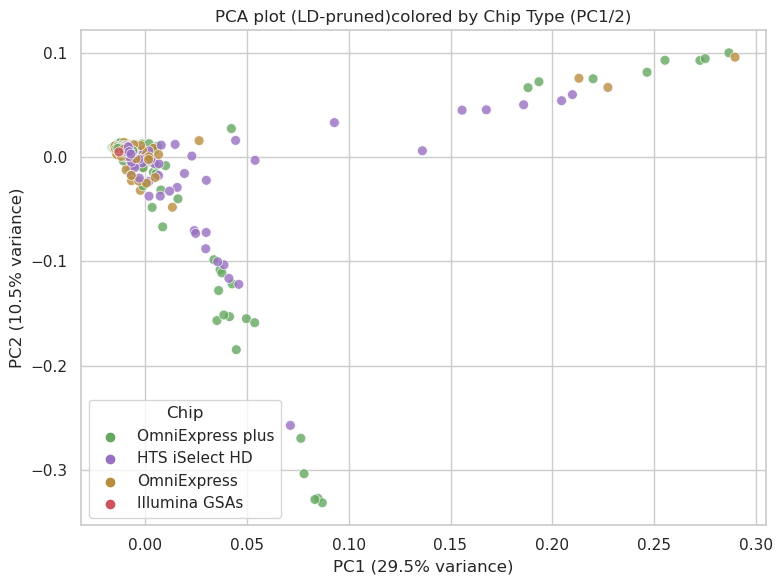

In [7]:
# the final plot
# Set plot style
sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

# yes, i am playing with the colours, don't judge
custom_palette = ["#64a860",
                  "#9970c1",
                  "#b98d3e",
                  "#cc545e"]

# Scatterplot of PC1 vs PC2 colored by chip
sns.scatterplot(
    data=merged,
    x='PC1',
    y='PC2',
    hue='chip',
    palette=custom_palette,
    s=50,
    alpha=0.8
)

plt.title('PCA plot (LD-pruned)colored by Chip Type (PC1/2)')
plt.xlabel(f'PC1 ({pc1_var:.1f}% variance)')
plt.ylabel(f'PC2 ({pc2_var:.1f}% variance)')
plt.legend(title='Chip')
plt.tight_layout()
plt.show()

/tmp/62599663/ipykernel_3899716/215398614.py:4: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.scatterplot(


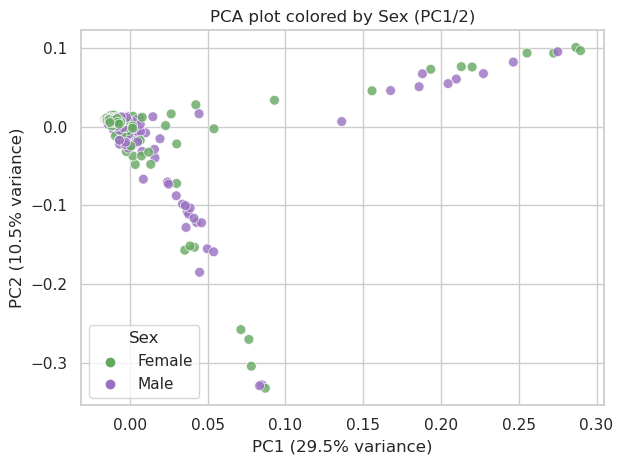

In [8]:
# i want to do another pca plot to see if gender makes any difference
# and because it is fun, also PC2 and PC3
# Scatterplot of PC1 vs PC2 colored by chip
sns.scatterplot(
    data=merged,
    x='PC1',
    y='PC2',
    hue='inferred_sex',
    palette=custom_palette,
    s=50,
    alpha=0.8
)

plt.title('PCA plot colored by Sex (PC1/2)')
plt.xlabel(f'PC1 ({pc1_var:.1f}% variance)')
plt.ylabel(f'PC2 ({pc2_var:.1f}% variance)')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()